# Self-Consistency Study — Vulnerability Detection

How does **self-consistency** (sampling the same prompt N times and aggregating the votes)
affect **FNR**, **F1**, and **accuracy** for binary vulnerability detection?

**Data.** `self_consistency` plan, model `qwen3-8b-thinking-sc15` (15 stochastic passes,
temperature 0.9), prompt `strict_exploitable_security`, dataset
`context_assembler_compare_multiplicative_amplification` (n = 498). Each snippet stores all 15 raw responses; we
re-parse them **in order** with the framework's own `BinaryResponseParser`, so a prediction
"at K passes" uses the **first K** votes.

**Aggregation counts.** K ∈ {1, 3, 5, 7, 11, 15}.

**Aggregation rules** (one cell each):
1. **Majority voting** — flag vulnerable iff `count₁/K > 0.5`.
2. **Vulnerability-sensitive threshold voting** — flag vulnerable iff `count₁/K ≥ t`, for
   t ∈ {0.25, 0.33, 0.50}. Lower t = more sensitive ⇒ lower FNR.
3. **OR voting** — flag vulnerable iff **any** of the K passes flags it.

At **K = 1** every rule reduces to the single pass-1 vote, so **K = 1 is the stochastic
single-pass baseline**, shared across all rules.

**Reporting** (each rule cell):
- absolute metric values vs K;
- absolute improvement over the single-pass baseline (Δ vs K = 1);
- 95% confidence intervals from a **paired bootstrap over snippets** (B = 2000, fixed seed);
- the faint band around the baseline shows the spread (±1 std) of the 15 *individual* passes,
  i.e. the noise of a stochastic single pass.

**Optimal K** is defined *before* the final test (Section 6) and the **final selected
configuration** is then compared against single-pass inference with **McNemar's test**
(Section 7).

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, binomtest

PROJECT_ROOT = Path("__file__").resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from benchmark.response_parser import BinaryResponseParser

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ---- study configuration ----
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "context_assembler_compare_rankings_experiments"
    / "self_consistency"
)
MODEL_DIR = "qwen3-8b-thinking-sc15"
PROMPT = "strict_exploitable_security"
PRIMARY_DATASET = "context_assembler_compare_multiplicative_amplification"
N_PASSES = 15
K_LIST = [1, 3, 5, 7, 11, 15]
B_BOOT = 2000          # paired-bootstrap resamples
SEED = 20260613
THRESHOLDS = [0.25, 0.33, 0.50]
F1_TOL = 0.01          # 1 percentage-point tolerance for optimal-K

parser = BinaryResponseParser()
print("Results dir:", RESULTS_DIR)

Results dir: /var/opt/llm4codesec-framework/results/context_assembler_compare_rankings_experiments/self_consistency


## 1. Load data & build the vote matrix

For each completed sc15 report we parse the 15 responses per snippet into an ordered binary
vote vector. `V` has shape `(n_snippets, 15)`; `y_true` is the ground-truth label.

In [2]:
def load_votes(dataset: str):
    # Return (V, y_true) for one dataset, parsing the 15 responses in order.
    base = RESULTS_DIR / dataset / MODEL_DIR / PROMPT
    reports = sorted(base.glob("benchmark_report_*.json"))
    if not reports:
        return None
    rep = json.load(open(reports[-1]))
    V, y = [], []
    for pred in rep["predictions"]:
        idd = pred.get("inference_data") or {}
        resp = idd.get("responses") or []
        if len(resp) != N_PASSES:
            continue  # skip incomplete snippets (runs still in progress)
        V.append([parser.parse_response(t) for t in resp])
        y.append(int(pred["true_label"]))
    return np.array(V, dtype=int), np.array(y, dtype=int)

# discover every completed sc15 dataset (primary first)
available = {}
for ds_dir in sorted(RESULTS_DIR.glob("*")):
    if not (ds_dir / MODEL_DIR / PROMPT).is_dir():
        continue
    res = load_votes(ds_dir.name)
    if res is not None and len(res[1]) > 0:
        available[ds_dir.name] = res

assert PRIMARY_DATASET in available, f"Primary dataset {PRIMARY_DATASET} not found/complete"
V, y_true = available[PRIMARY_DATASET]
N = len(y_true)

print(f"Completed sc15 datasets: {list(available)}")
print(f"\nPrimary = {PRIMARY_DATASET}")
print(f"  snippets : {N}")
print(f"  pos rate : {y_true.mean():.3f}")
print(f"  per-pass mean vulnerable-vote rate: {V.mean(axis=0).round(3)}")

Completed sc15 datasets: ['context_assembler_compare_cpg_structural', 'context_assembler_compare_current', 'context_assembler_compare_current_default', 'context_assembler_compare_depth_repeats_context', 'context_assembler_compare_dummy', 'context_assembler_compare_evidence_budgeted', 'context_assembler_compare_multiplicative_amplification', 'context_assembler_compare_multiplicative_amplification_default', 'context_assembler_compare_random_picking']

Primary = context_assembler_compare_multiplicative_amplification
  snippets : 498
  pos rate : 0.500
  per-pass mean vulnerable-vote rate: [0.544 0.514 0.546 0.53  0.532 0.528 0.506 0.558 0.546 0.518 0.522 0.542
 0.528 0.5   0.534]


## 2. Core machinery — predictions, metrics, paired bootstrap

- `predict(V, K, rule, t)` applies an aggregation rule to the **first K** votes.
- `metrics_from_pred` returns accuracy / precision / recall / F1 / **FNR** (= FN/(FN+TP) = 1−recall).
- `bootstrap_ci` resamples snippets with replacement (paired: the same resampled index set is
  used for the config and the baseline) to give 95% CIs for absolute metrics and for the
  improvement Δ over the single-pass baseline.
- `report_rule` is the shared engine each rule cell calls so that **one cell = one rule**.

In [3]:
METRICS = ["fnr", "f1", "accuracy"]
METRIC_LABEL = {"fnr": "FNR (lower better)", "f1": "F1 score", "accuracy": "Accuracy"}

def predict(V, K, rule, t=0.5):
    c1 = V[:, :K].sum(axis=1)
    frac = c1 / K
    if rule == "majority":
        return (frac > 0.5).astype(int)
    if rule == "threshold":
        return (frac >= t).astype(int)
    if rule == "or":
        return (c1 >= 1).astype(int)
    raise ValueError(rule)

def metrics_from_pred(y_true, y_pred):
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    n = len(y_true)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    return {
        "accuracy": (tp + tn) / n,
        "precision": prec,
        "recall": rec,
        "f1": 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0,
        "fnr": fn / (fn + tp) if (fn + tp) else 0.0,
    }

# single-pass stochastic baseline = pass-1 vote (== predict(V, 1, any rule))
baseline_pred = predict(V, 1, "majority")
baseline_metrics = metrics_from_pred(y_true, baseline_pred)

# per-pass spread: treat each of the 15 passes as its own single-pass run
per_pass = [metrics_from_pred(y_true, V[:, i]) for i in range(N_PASSES)]
per_pass_stats = {
    m: (np.mean([p[m] for p in per_pass]), np.std([p[m] for p in per_pass]))
    for m in METRICS
}

def bootstrap_ci(V, y_true, K, rule, t=0.5, baseline_pred=None, B=B_BOOT, seed=SEED):
    # Paired bootstrap over snippets -> (abs CI dict, delta CI dict).
    rng = np.random.default_rng(seed)
    n = len(y_true)
    y_pred = predict(V, K, rule, t)
    msamp = {m: np.empty(B) for m in METRICS}
    dsamp = {m: np.empty(B) for m in METRICS}
    for b in range(B):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        mm = metrics_from_pred(yt, yp)
        for m in METRICS:
            msamp[m][b] = mm[m]
        if baseline_pred is not None:
            bm = metrics_from_pred(yt, baseline_pred[idx])
            for m in METRICS:
                dsamp[m][b] = mm[m] - bm[m]
    ci = {m: (np.percentile(msamp[m], 2.5), np.percentile(msamp[m], 97.5)) for m in METRICS}
    dci = (
        {m: (np.percentile(dsamp[m], 2.5), np.percentile(dsamp[m], 97.5)) for m in METRICS}
        if baseline_pred is not None else None
    )
    return ci, dci

def compute_rule(configs):
    # For each config={label,rule,t}, sweep K -> point estimates + bootstrap CIs.
    # Returns a tidy DataFrame with one row per (config, K, metric).
    rows = []
    for cfg in configs:
        for K in K_LIST:
            point = metrics_from_pred(y_true, predict(V, K, cfg["rule"], cfg.get("t", 0.5)))
            ci, dci = bootstrap_ci(V, y_true, K, cfg["rule"], cfg.get("t", 0.5), baseline_pred)
            for m in METRICS:
                rows.append({
                    "config": cfg["label"], "K": K, "metric": m,
                    "value": point[m],
                    "ci_lo": ci[m][0], "ci_hi": ci[m][1],
                    "delta": point[m] - baseline_metrics[m],
                    "d_lo": dci[m][0], "d_hi": dci[m][1],
                })
    return pd.DataFrame(rows)

def report_rule(title, configs):
    # Plot absolute metrics + improvement-over-baseline with CIs, print a table.
    df = compute_rule(configs)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(configs), 3)))
    for j, m in enumerate(METRICS):
        ax_abs, ax_delta = axes[0, j], axes[1, j]
        # baseline reference + per-pass spread band
        mu, sd = per_pass_stats[m]
        ax_abs.axhspan(mu - sd, mu + sd, color="grey", alpha=0.15,
                       label="single-pass ±1 std" if j == 0 else None)
        ax_abs.axhline(baseline_metrics[m], color="grey", ls="--", lw=1,
                       label="single-pass (K=1)" if j == 0 else None)
        ax_delta.axhline(0, color="grey", ls="--", lw=1)
        for ci_, cfg in enumerate(configs):
            sub = df[(df.config == cfg["label"]) & (df.metric == m)].sort_values("K")
            col = colors[ci_]
            ax_abs.plot(sub.K, sub.value, "-o", color=col, label=cfg["label"])
            ax_abs.fill_between(sub.K, sub.ci_lo, sub.ci_hi, color=col, alpha=0.15)
            ax_delta.plot(sub.K, sub.delta, "-o", color=col, label=cfg["label"])
            ax_delta.fill_between(sub.K, sub.d_lo, sub.d_hi, color=col, alpha=0.15)
        ax_abs.set_title(METRIC_LABEL[m])
        ax_delta.set_title(f"Δ {METRIC_LABEL[m]} vs single-pass")
        ax_delta.set_xlabel("K (passes aggregated)")
        ax_abs.set_xticks(K_LIST); ax_delta.set_xticks(K_LIST)
    axes[0, 0].set_ylabel("absolute value")
    axes[1, 0].set_ylabel("improvement (Δ)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, y=1.06, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

    # compact wide table: value [95% CI]  and  Δ [95% CI]
    show = df.copy()
    show["value [95% CI]"] = show.apply(
        lambda r: f"{r.value:.3f} [{r.ci_lo:.3f}, {r.ci_hi:.3f}]", axis=1)
    show["Δ vs 1-pass [95% CI]"] = show.apply(
        lambda r: f"{r.delta:+.3f} [{r.d_lo:+.3f}, {r.d_hi:+.3f}]", axis=1)
    piv = show.pivot_table(index=["config", "K"], columns="metric",
                           values=["value [95% CI]", "Δ vs 1-pass [95% CI]"],
                           aggfunc="first")
    from IPython.display import display
    display(piv)
    return df

## 3. Rule A — Majority voting

Flag vulnerable iff a strict majority of the K passes voted vulnerable. The conventional
self-consistency rule. Top row = absolute metric vs K with 95% bootstrap bands; bottom row =
improvement over the single-pass baseline (a Δ band that excludes 0 means the change is
significant at 95%).

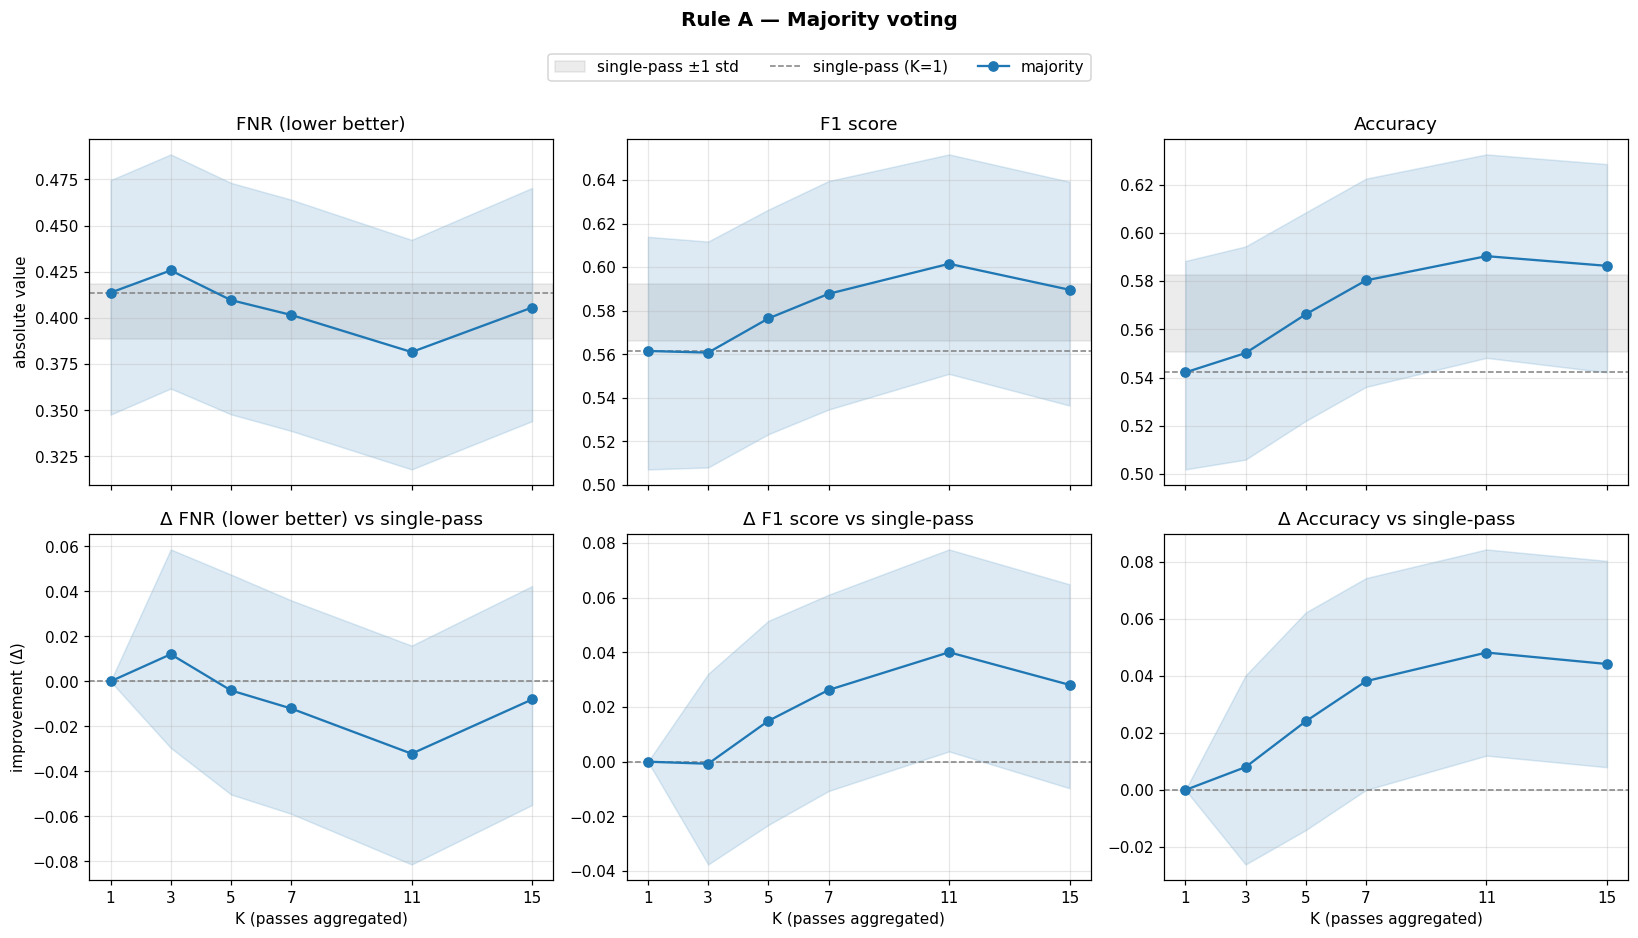

value [95% CI]                                              \
metric                   accuracy                    f1                   fnr   
config   K                                                                      
majority 1   0.542 [0.502, 0.588]  0.562 [0.507, 0.614]  0.414 [0.348, 0.475]   
         3   0.550 [0.506, 0.594]  0.561 [0.508, 0.612]  0.426 [0.362, 0.488]   
         5   0.566 [0.522, 0.608]  0.576 [0.523, 0.626]  0.410 [0.348, 0.473]   
         7   0.580 [0.536, 0.622]  0.588 [0.535, 0.640]  0.402 [0.339, 0.464]   
         11  0.590 [0.548, 0.633]  0.602 [0.551, 0.652]  0.382 [0.318, 0.442]   
         15  0.586 [0.542, 0.629]  0.590 [0.536, 0.639]  0.406 [0.344, 0.470]   

                Δ vs 1-pass [95% CI]                           \
metric                      accuracy                       f1   
config   K                                                      
majority 1   +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]   
         3   +0.008 [-0.026, +0.040]  -0.001 [-0.038, +0.032]   
         5   +0.024 [-0.014, +0.062]  +0.015 [-0.023, +0.052]   
         7   +0.038 [+0.000, +0.074]  +0.026 [-0.011, +0.061]   
         11  +0.048 [+0.012, +0.084]  +0.040 [+0.004, +0.078]   
         15  +0.044 [+0.008, +0.080]  +0.028 [-0.010, +0.065]   

                                      
metric                           fnr  
config   K                            
majority 1   +0.000 [+0.000, +0.000]  
         3   +0.012 [-0.030, +0.059]  
         5   -0.004 [-0.050, +0.047]  
         7   -0.012 [-0.059, +0.036]  
         11  -0.032 [-0.081, +0.016]  
         15  -0.008 [-0.055, +0.042]

In [4]:
df_majority = report_rule("Rule A — Majority voting", [{"label": "majority", "rule": "majority"}])

## 4. Rule B — Vulnerability-sensitive threshold voting

Flag vulnerable iff `count₁/K ≥ t`. Three sensitivity levels are overlaid: **t = 0.25**,
**0.33**, **0.50**. Lower thresholds escalate weak signals, trading specificity for a lower
**FNR** — the security-relevant trade-off (missing a real vulnerability is costly).

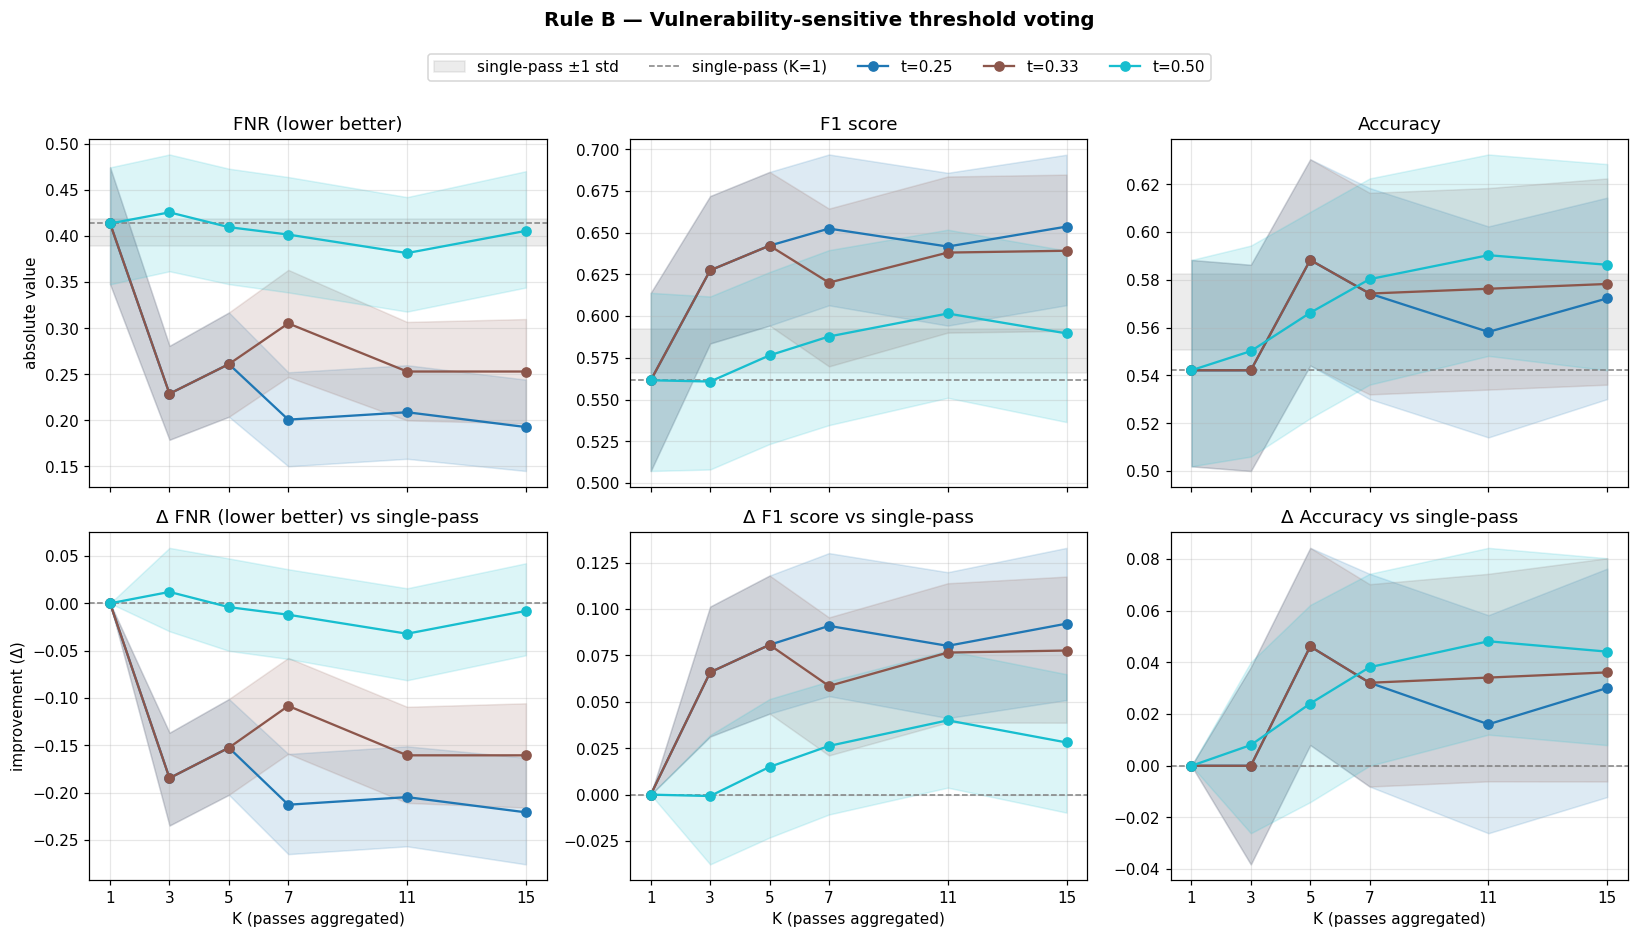

value [95% CI]                                              \
metric                 accuracy                    f1                   fnr   
config K                                                                      
t=0.25 1   0.542 [0.502, 0.588]  0.562 [0.507, 0.614]  0.414 [0.348, 0.475]   
       3   0.542 [0.500, 0.586]  0.627 [0.584, 0.672]  0.229 [0.179, 0.281]   
       5   0.588 [0.544, 0.631]  0.642 [0.594, 0.686]  0.261 [0.204, 0.317]   
       7   0.574 [0.530, 0.618]  0.652 [0.606, 0.697]  0.201 [0.150, 0.252]   
       11  0.558 [0.514, 0.602]  0.642 [0.594, 0.686]  0.209 [0.158, 0.260]   
       15  0.572 [0.530, 0.614]  0.654 [0.607, 0.697]  0.193 [0.145, 0.244]   
t=0.33 1   0.542 [0.502, 0.588]  0.562 [0.507, 0.614]  0.414 [0.348, 0.475]   
       3   0.542 [0.500, 0.586]  0.627 [0.584, 0.672]  0.229 [0.179, 0.281]   
       5   0.588 [0.544, 0.631]  0.642 [0.594, 0.686]  0.261 [0.204, 0.317]   
       7   0.574 [0.532, 0.616]  0.620 [0.570, 0.664]  0.305 [0.247, 0.363]   
       11  0.576 [0.534, 0.618]  0.638 [0.590, 0.684]  0.253 [0.200, 0.307]   
       15  0.578 [0.536, 0.622]  0.639 [0.591, 0.685]  0.253 [0.197, 0.310]   
t=0.50 1   0.542 [0.502, 0.588]  0.562 [0.507, 0.614]  0.414 [0.348, 0.475]   
       3   0.550 [0.506, 0.594]  0.561 [0.508, 0.612]  0.426 [0.362, 0.488]   
       5   0.566 [0.522, 0.608]  0.576 [0.523, 0.626]  0.410 [0.348, 0.473]   
       7   0.580 [0.536, 0.622]  0.588 [0.535, 0.640]  0.402 [0.339, 0.464]   
       11  0.590 [0.548, 0.633]  0.602 [0.551, 0.652]  0.382 [0.318, 0.442]   
       15  0.586 [0.542, 0.629]  0.590 [0.536, 0.639]  0.406 [0.344, 0.470]   

              Δ vs 1-pass [95% CI]                           \
metric                    accuracy                       f1   
config K                                                      
t=0.25 1   +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]   
       3   +0.000 [-0.038, +0.038]  +0.066 [+0.031, +0.101]   
       5   +0.046 [+0.008, +0.084]  +0.081 [+0.044, +0.118]   
       7   +0.032 [-0.008, +0.074]  +0.091 [+0.053, +0.130]   
       11  +0.016 [-0.026, +0.058]  +0.080 [+0.041, +0.120]   
       15  +0.030 [-0.012, +0.076]  +0.092 [+0.051, +0.133]   
t=0.33 1   +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]   
       3   +0.000 [-0.038, +0.038]  +0.066 [+0.031, +0.101]   
       5   +0.046 [+0.008, +0.084]  +0.081 [+0.044, +0.118]   
       7   +0.032 [-0.008, +0.070]  +0.059 [+0.021, +0.095]   
       11  +0.034 [-0.006, +0.074]  +0.077 [+0.039, +0.114]   
       15  +0.036 [-0.006, +0.080]  +0.078 [+0.039, +0.117]   
t=0.50 1   +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]   
       3   +0.008 [-0.026, +0.040]  -0.001 [-0.038, +0.032]   
       5   +0.024 [-0.014, +0.062]  +0.015 [-0.023, +0.052]   
       7   +0.038 [+0.000, +0.074]  +0.026 [-0.011, +0.061]   
       11  +0.048 [+0.012, +0.084]  +0.040 [+0.004, +0.078]   
       15  +0.044 [+0.008, +0.080]  +0.028 [-0.010, +0.065]   

                                    
metric                         fnr  
config K                            
t=0.25 1   +0.000 [+0.000, +0.000]  
       3   -0.185 [-0.235, -0.137]  
       5   -0.153 [-0.202, -0.101]  
       7   -0.213 [-0.265, -0.159]  
       11  -0.205 [-0.257, -0.151]  
       15  -0.221 [-0.276, -0.163]  
t=0.33 1   +0.000 [+0.000, +0.000]  
       3   -0.185 [-0.235, -0.137]  
       5   -0.153 [-0.202, -0.101]  
       7   -0.108 [-0.159, -0.058]  
       11  -0.161 [-0.211, -0.109]  
       15  -0.161 [-0.216, -0.106]  
t=0.50 1   +0.000 [+0.000, +0.000]  
       3   +0.012 [-0.030, +0.059]  
       5   -0.004 [-0.050, +0.047]  
       7   -0.012 [-0.059, +0.036]  
       11  -0.032 [-0.081, +0.016]  
       15  -0.008 [-0.055, +0.042]

In [5]:
df_threshold = report_rule(
    "Rule B — Vulnerability-sensitive threshold voting",
    [{"label": f"t={t:.2f}", "rule": "threshold", "t": t} for t in THRESHOLDS],
)

## 5. Rule C — OR voting

Flag vulnerable iff **any** of the K passes flags it (`t → 1/K`). The most sensitive rule:
FNR should fall fastest as K grows, at the largest specificity cost.

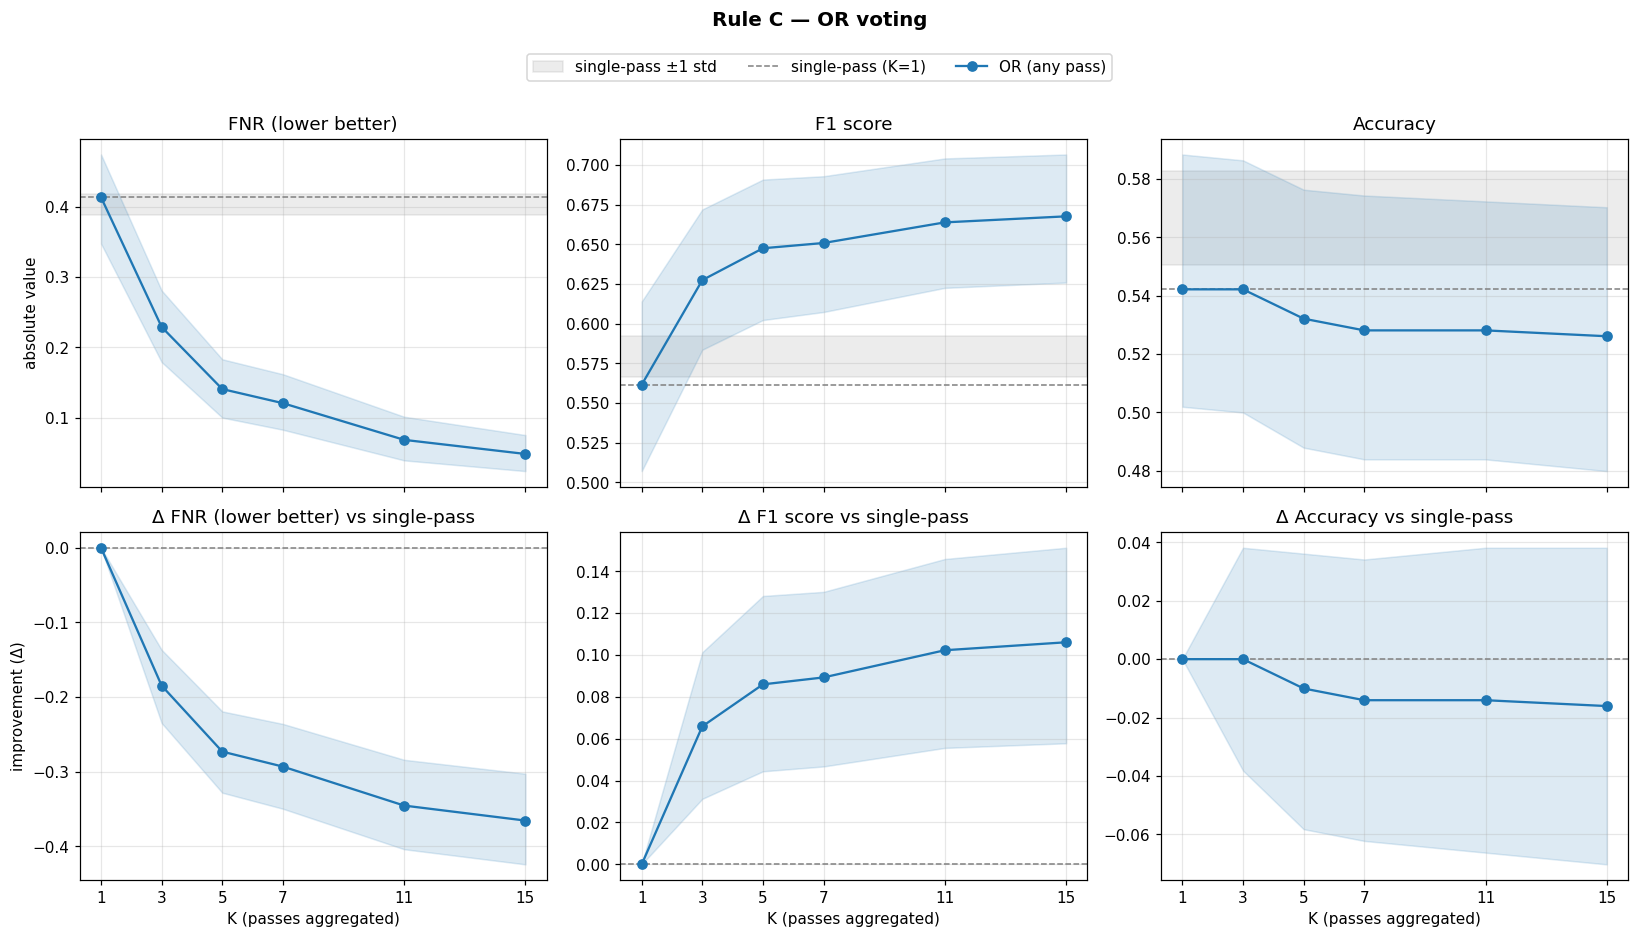

value [95% CI]                        \
metric                        accuracy                    f1   
config        K                                                
OR (any pass) 1   0.542 [0.502, 0.588]  0.562 [0.507, 0.614]   
              3   0.542 [0.500, 0.586]  0.627 [0.584, 0.672]   
              5   0.532 [0.488, 0.576]  0.648 [0.602, 0.691]   
              7   0.528 [0.484, 0.574]  0.651 [0.607, 0.693]   
              11  0.528 [0.484, 0.572]  0.664 [0.623, 0.704]   
              15  0.526 [0.480, 0.570]  0.668 [0.626, 0.707]   

                                           Δ vs 1-pass [95% CI]  \
metric                             fnr                 accuracy   
config        K                                                   
OR (any pass) 1   0.414 [0.348, 0.475]  +0.000 [+0.000, +0.000]   
              3   0.229 [0.179, 0.281]  +0.000 [-0.038, +0.038]   
              5   0.141 [0.100, 0.183]  -0.010 [-0.058, +0.036]   
              7   0.120 [0.083, 0.162]  -0.014 [-0.062, +0.034]   
              11  0.068 [0.039, 0.101]  -0.014 [-0.066, +0.038]   
              15  0.048 [0.024, 0.075]  -0.016 [-0.070, +0.038]   

                                                                    
metric                                 f1                      fnr  
config        K                                                     
OR (any pass) 1   +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]  
              3   +0.066 [+0.031, +0.101]  -0.185 [-0.235, -0.137]  
              5   +0.086 [+0.044, +0.128]  -0.273 [-0.328, -0.219]  
              7   +0.089 [+0.047, +0.130]  -0.293 [-0.350, -0.236]  
              11  +0.102 [+0.056, +0.146]  -0.345 [-0.404, -0.284]  
              15  +0.106 [+0.058, +0.151]  -0.365 [-0.424, -0.303]

In [6]:
df_or = report_rule("Rule C — OR voting", [{"label": "OR (any pass)", "rule": "or"}])

## 6. Optimal K — defined *before* the final test

**Criterion.** Within an aggregation rule, the optimal K is the **smallest** K whose

1. **F1 is within 1 percentage point** of the best observed F1 for that rule, **and**
2. **FNR is not significantly worse** than the rule's lowest observed FNR — operationalized as:
   the paired-bootstrap 95% CI of `FNR_K − FNR_(min-FNR K)` **includes 0**.

We compute the optimal K for every rule/threshold, then (the "decide-in-notebook" policy)
**auto-select the final configuration**: among each rule's optimal-K candidate, take the
highest F1; break ties within 1 pp by the lowest FNR.

In [7]:
def optimal_K(rule, t=0.5, B=B_BOOT, seed=SEED):
    f1s = {K: metrics_from_pred(y_true, predict(V, K, rule, t))["f1"] for K in K_LIST}
    fnrs = {K: metrics_from_pred(y_true, predict(V, K, rule, t))["fnr"] for K in K_LIST}
    best_f1 = max(f1s.values())
    K_minfnr = min(fnrs, key=fnrs.get)
    pred_minfnr = predict(V, K_minfnr, rule, t)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    chosen, detail = None, {}
    for K in K_LIST:
        within = f1s[K] >= best_f1 - F1_TOL
        pK = predict(V, K, rule, t)
        diffs = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, n, n)
            yt = y_true[idx]
            diffs[b] = (metrics_from_pred(yt, pK[idx])["fnr"]
                        - metrics_from_pred(yt, pred_minfnr[idx])["fnr"])
        lo, hi = np.percentile(diffs, 2.5), np.percentile(diffs, 97.5)
        not_worse = (lo <= 0 <= hi) or (K == K_minfnr)
        detail[K] = dict(f1=f1s[K], fnr=fnrs[K], within=within,
                         not_worse=not_worse, diff_ci=(lo, hi))
        if within and not_worse and chosen is None:
            chosen = K
    return chosen, detail, best_f1, K_minfnr

RULES = [("majority", "majority", 0.5)] \
    + [(f"threshold t={t:.2f}", "threshold", t) for t in THRESHOLDS] \
    + [("OR", "or", 0.5)]

cand_rows = []
for label, rule, t in RULES:
    K_opt, detail, best_f1, K_minfnr = optimal_K(rule, t)
    print(f"\n=== {label} ===  best_f1={best_f1:.4f}  min-FNR at K={K_minfnr}  ->  optimal K = {K_opt}")
    for K, d in detail.items():
        flag = " <= optimal" if K == K_opt else ""
        print(f"   K={K:2d}  f1={d['f1']:.4f}  fnr={d['fnr']:.4f}  "
              f"within1pp={str(d['within']):5s}  fnr_not_worse={str(d['not_worse']):5s}  "
              f"ΔFNR CI=[{d['diff_ci'][0]:+.3f},{d['diff_ci'][1]:+.3f}]{flag}")
    if K_opt is not None:
        mm = metrics_from_pred(y_true, predict(V, K_opt, rule, t))
        cand_rows.append(dict(label=label, rule=rule, t=t, K=K_opt,
                              f1=mm["f1"], fnr=mm["fnr"], accuracy=mm["accuracy"]))

cand = pd.DataFrame(cand_rows)
print("\n\nOptimal-K candidates per rule:")
display(cand.round(4))


=== majority ===  best_f1=0.6016  min-FNR at K=11  ->  optimal K = 11
   K= 1  f1=0.5615  fnr=0.4137  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.016,+0.081]
   K= 3  f1=0.5608  fnr=0.4257  within1pp=False  fnr_not_worse=True   ΔFNR CI=[+0.000,+0.091]
   K= 5  f1=0.5765  fnr=0.4096  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.008,+0.066]
   K= 7  f1=0.5878  fnr=0.4016  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.004,+0.046]
   K=11  f1=0.6016  fnr=0.3815  within1pp=True   fnr_not_worse=True   ΔFNR CI=[+0.000,+0.000] <= optimal
   K=15  f1=0.5896  fnr=0.4056  within1pp=False  fnr_not_worse=True   ΔFNR CI=[+0.000,+0.051]



=== threshold t=0.25 ===  best_f1=0.6537  min-FNR at K=15  ->  optimal K = 7
   K= 1  f1=0.5615  fnr=0.4137  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.163,+0.276]
   K= 3  f1=0.6275  fnr=0.2289  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.012,+0.084]
   K= 5  f1=0.6422  fnr=0.2610  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.027,+0.112]
   K= 7  f1=0.6525  fnr=0.2008  within1pp=True   fnr_not_worse=True   ΔFNR CI=[-0.025,+0.042] <= optimal
   K=11  f1=0.6417  fnr=0.2088  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.004,+0.040]
   K=15  f1=0.6537  fnr=0.1928  within1pp=True   fnr_not_worse=True   ΔFNR CI=[+0.000,+0.000]



=== threshold t=0.33 ===  best_f1=0.6422  min-FNR at K=3  ->  optimal K = 5
   K= 1  f1=0.5615  fnr=0.4137  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.137,+0.235]
   K= 3  f1=0.6275  fnr=0.2289  within1pp=False  fnr_not_worse=True   ΔFNR CI=[+0.000,+0.000]
   K= 5  f1=0.6422  fnr=0.2610  within1pp=True   fnr_not_worse=True   ΔFNR CI=[+0.000,+0.066] <= optimal
   K= 7  f1=0.6201  fnr=0.3052  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.034,+0.118]
   K=11  f1=0.6381  fnr=0.2530  within1pp=True   fnr_not_worse=True   ΔFNR CI=[-0.020,+0.068]
   K=15  f1=0.6392  fnr=0.2530  within1pp=True   fnr_not_worse=True   ΔFNR CI=[-0.024,+0.073]



=== threshold t=0.50 ===  best_f1=0.6016  min-FNR at K=11  ->  optimal K = 11
   K= 1  f1=0.5615  fnr=0.4137  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.016,+0.081]
   K= 3  f1=0.5608  fnr=0.4257  within1pp=False  fnr_not_worse=True   ΔFNR CI=[+0.000,+0.091]
   K= 5  f1=0.5765  fnr=0.4096  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.008,+0.066]
   K= 7  f1=0.5878  fnr=0.4016  within1pp=False  fnr_not_worse=True   ΔFNR CI=[-0.004,+0.046]
   K=11  f1=0.6016  fnr=0.3815  within1pp=True   fnr_not_worse=True   ΔFNR CI=[+0.000,+0.000] <= optimal
   K=15  f1=0.5896  fnr=0.4056  within1pp=False  fnr_not_worse=True   ΔFNR CI=[+0.000,+0.051]



=== OR ===  best_f1=0.6676  min-FNR at K=15  ->  optimal K = 15
   K= 1  f1=0.5615  fnr=0.4137  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.303,+0.424]
   K= 3  f1=0.6275  fnr=0.2289  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.136,+0.228]
   K= 5  f1=0.6475  fnr=0.1406  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.058,+0.130]
   K= 7  f1=0.6508  fnr=0.1205  within1pp=False  fnr_not_worse=False  ΔFNR CI=[+0.042,+0.107]
   K=11  f1=0.6638  fnr=0.0683  within1pp=True   fnr_not_worse=False  ΔFNR CI=[+0.004,+0.038]
   K=15  f1=0.6676  fnr=0.0482  within1pp=True   fnr_not_worse=True   ΔFNR CI=[+0.000,+0.000] <= optimal


Optimal-K candidates per rule:


,label,rule,t,K,f1,fnr,accuracy
0,majority,majority,0.50,11,0.6016,0.3815,0.5904
1,threshold t=0.25,threshold,0.25,7,0.6525,0.2008,0.5743
2,threshold t=0.33,threshold,0.33,5,0.6422,0.2610,0.5884
3,threshold t=0.50,threshold,0.50,11,0.6016,0.3815,0.5904
4,OR,or,0.50,15,0.6676,0.0482,0.5261


In [8]:
# auto-select final configuration: best F1, tie-break (within 1pp) by lowest FNR
best_accuracy_overall = cand.accuracy.max()
contenders = cand[cand.accuracy >= best_accuracy_overall - F1_TOL]
final = contenders.sort_values(["accuracy", "fnr"], ascending=[False, True]).iloc[0]
print("Contenders within 1pp of best Accuracy:")
display(contenders.round(4))
print(f"\n>>> FINAL SELECTED CONFIGURATION: {final.label}  at K = {int(final.K)}")
print(f"    F1={final.f1:.4f}  FNR={final.fnr:.4f}  Accuracy={final.accuracy:.4f}")

Contenders within 1pp of best Accuracy:


,label,rule,t,K,f1,fnr,accuracy
0,majority,majority,0.50,11,0.6016,0.3815,0.5904
2,threshold t=0.33,threshold,0.33,5,0.6422,0.2610,0.5884
3,threshold t=0.50,threshold,0.50,11,0.6016,0.3815,0.5904



>>> FINAL SELECTED CONFIGURATION: majority  at K = 11
    F1=0.6016  FNR=0.3815  Accuracy=0.5904


## 7. Final test — McNemar vs single-pass inference

The pre-registered final configuration is compared against the stochastic single-pass
predictor (K = 1) using **McNemar's test** on paired binary correctness. We report the
discordant counts, McNemar's χ² (continuity-corrected) with its p-value, and the exact
binomial p-value, alongside the paired-bootstrap 95% CIs of the metric improvements.

In [9]:
final_pred = predict(V, int(final.K), final.rule, final.t)
final_metrics = metrics_from_pred(y_true, final_pred)

sc_correct = (final_pred == y_true)
sp_correct = (baseline_pred == y_true)
both = int(np.sum(sc_correct & sp_correct))
b = int(np.sum(sp_correct & ~sc_correct))   # single-pass right, self-consistency wrong
c = int(np.sum(~sp_correct & sc_correct))   # self-consistency right, single-pass wrong
neither = int(np.sum(~sc_correct & ~sp_correct))

chi2_stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) else 0.0
p_chi2 = float(1 - chi2.cdf(chi2_stat, 1))
p_exact = float(binomtest(min(b, c), b + c, 0.5).pvalue) if (b + c) else 1.0

print("Paired correctness (final self-consistency vs single-pass):")
print(pd.DataFrame(
    [[both, b], [c, neither]],
    index=["single-pass correct", "single-pass wrong"],
    columns=["SC correct", "SC wrong"],
))
print(f"\nDiscordant pairs: b (single-only)={b}, c (SC-only)={c}")
print(f"McNemar chi^2 (cont. corrected) = {chi2_stat:.3f}   p = {p_chi2:.4f}")
print(f"Exact binomial p               = {p_exact:.4f}")

# bootstrap CI of the improvement of the final config over single-pass
_, dci = bootstrap_ci(V, y_true, int(final.K), final.rule, final.t, baseline_pred)
print("\nImprovement over single-pass (Δ, 95% paired-bootstrap CI):")
for m in METRICS:
    d = final_metrics[m] - baseline_metrics[m]
    print(f"  {METRIC_LABEL[m]:22s}: {final_metrics[m]:.4f} vs {baseline_metrics[m]:.4f} "
          f"  Δ={d:+.4f}  [{dci[m][0]:+.4f}, {dci[m][1]:+.4f}]")

verdict = "significant" if min(p_chi2, p_exact) < 0.05 else "NOT significant"
print(f"\nVerdict: the difference vs single-pass is {verdict} at α=0.05.")

Paired correctness (final self-consistency vs single-pass):
                     SC correct  SC wrong
single-pass correct         239        31
single-pass wrong            55       173

Discordant pairs: b (single-only)=31, c (SC-only)=55
McNemar chi^2 (cont. corrected) = 6.151   p = 0.0131
Exact binomial p               = 0.0127

Improvement over single-pass (Δ, 95% paired-bootstrap CI):
  FNR (lower better)    : 0.3815 vs 0.4137   Δ=-0.0321  [-0.0813, +0.0159]
  F1 score              : 0.6016 vs 0.5615   Δ=+0.0400  [+0.0038, +0.0776]
  Accuracy              : 0.5904 vs 0.5422   Δ=+0.0482  [+0.0120, +0.0843]

Verdict: the difference vs single-pass is significant at α=0.05.


## 8. Cost-effectiveness — is each extra pass worth it?

Self-consistency cost grows **~linearly in K** (each pass re-processes the prompt and generates
a fresh answer), while the metric gains diminish — so more passes are not free. Per-pass timing
was only logged as an aggregate average, so cost here is modelled from the **measured
per-snippet token totals** plus a **constant-throughput** assumption (single GPU):

- generated (output) tokens per pass ≈ `response_chars / 4`;
- prompt tokens per pass (constant within a snippet) = `(measured 15-pass total − Σ generated) / 15`, clipped ≥ 0;
- cost of the first K passes = `K · prompt_per_pass + Σ generated(passes 1..K)`;
- latency = `tokens / throughput`, throughput = `total_tokens / total_wall_time` (≈ 3.6k tok/s here);
- **GPU-hours assume 1 device** — scale by your device count if the run used more.

We report, per K: **mean/median latency per sample**, **total generated tokens**, **total
tokens**, **GPU-hours**, and the **marginal metric gain per additional pass**; then plot
**F1 vs cost** and **FNR vs cost**. This is the crux of the headline finding: OR voting at
K = 15 yields the strongest FNR reduction but also the highest inference cost (≈ 15× single-pass).

In [10]:
from IPython.display import display

# ---- Cost model (assumptions described in the markdown above) ----
CHARS_PER_TOKEN = 4.0   # proxy: generated tokens per pass ~= response_chars / 4
N_GPUS = 1              # GPU-hours assume a single device; scale by your device count

_costrep = json.load(open(sorted(
    (RESULTS_DIR / PRIMARY_DATASET / MODEL_DIR / PROMPT).glob("benchmark_report_*.json"))[-1]))
_cstats = _costrep["benchmark_info"]["stats"]
TOTAL_WALL_S = _cstats["total_time_seconds"]
TOKENS_TOTAL_15 = _cstats["tokens_used_total"]
THROUGHPUT_TPS = TOKENS_TOTAL_15 / TOTAL_WALL_S            # constant-throughput model

_char_len, _tok15 = [], []
for p in _costrep["predictions"]:
    idd = p["inference_data"]
    if len(idd.get("responses", [])) != N_PASSES:
        continue
    _char_len.append([len(r) for r in idd["responses"]])
    _tok15.append(idd["tokens_used"])
_char_len = np.array(_char_len, dtype=float)              # (N, 15) response char lengths
_tok15 = np.array(_tok15, dtype=float)                    # (N,) measured 15-pass token totals
gen_tok = _char_len / CHARS_PER_TOKEN                     # est. generated tokens per pass
prompt_per_pass = np.clip((_tok15 - gen_tok.sum(axis=1)) / N_PASSES, 0, None)  # (N,)

def cost_at_K(K):
    # cost of using the first K passes, per snippet -> (generated, total, latency_seconds)
    gen_K = gen_tok[:, :K].sum(axis=1)
    total_K = prompt_per_pass * K + gen_K                 # prompt re-sent each pass + generated
    latency_K = total_K / THROUGHPUT_TPS
    return gen_K, total_K, latency_K

def metrics_at(K, rule, t=0.5):
    return metrics_from_pred(y_true, predict(V, K, rule, t))

print(f"Throughput model : {THROUGHPUT_TPS:,.0f} tokens/s  "
      f"({TOKENS_TOTAL_15:,} tok over {TOTAL_WALL_S / 60:.1f} min wall, {N_GPUS} GPU)")
print(f"Per pass (median): prompt {np.median(prompt_per_pass):,.0f} tok, "
      f"generated {np.median(gen_tok):,.0f} tok")

# --- per-K physical cost (identical across aggregation rules) ---
base_total = cost_at_K(1)[1].sum()
cost_rows = []
for K in K_LIST:
    gen_K, total_K, lat_K = cost_at_K(K)
    cost_rows.append({
        "K": K,
        "latency/sample mean (s)": lat_K.mean(),
        "latency/sample median (s)": np.median(lat_K),
        "generated tokens (M)": gen_K.sum() / 1e6,
        "total tokens (M)": total_K.sum() / 1e6,
        "GPU-hours": total_K.sum() / THROUGHPUT_TPS / 3600 * N_GPUS,
        "cost vs K=1 (x)": total_K.sum() / base_total,
    })
cost_df = pd.DataFrame(cost_rows).set_index("K")
print("\nPer-K inference cost (physical cost is the same for every aggregation rule):")
display(cost_df.round(3))

# --- marginal metric gain per additional pass (majority vs OR extremes) ---
ref_rules = [("majority", "majority", 0.5), ("OR", "or", 0.5)]
marg_rows = []
for i in range(1, len(K_LIST)):
    K0, K1 = K_LIST[i - 1], K_LIST[i]
    d_tokM = (cost_at_K(K1)[1].sum() - cost_at_K(K0)[1].sum()) / 1e6
    row = {"K step": f"{K0}->{K1}", "Δtotal tokens (M)": d_tokM}
    for lbl, rule, t in ref_rules:
        dF1 = metrics_at(K1, rule, t)["f1"] - metrics_at(K0, rule, t)["f1"]
        dFNR = metrics_at(K1, rule, t)["fnr"] - metrics_at(K0, rule, t)["fnr"]
        row[f"ΔF1/pass [{lbl}]"] = dF1 / (K1 - K0)
        row[f"ΔFNR/pass [{lbl}]"] = dFNR / (K1 - K0)
        row[f"ΔFNR per 1M tok [{lbl}]"] = dFNR / d_tokM
    marg_rows.append(row)
marg_df = pd.DataFrame(marg_rows).set_index("K step")
print("\nMarginal gain per additional pass (negative ΔFNR = improvement):")
display(marg_df.round(4))

Throughput model : 3,597 tokens/s  (17,364,764 tok over 80.5 min wall, 1 GPU)
Per pass (median): prompt 1,091 tok, generated 1,344 tok

Per-K inference cost (physical cost is the same for every aggregation rule):


,latency/sample mean (s),latency/sample median (s),generated tokens (M),total tokens (M),GPU-hours,cost vs K=1 (x)
K,,,,,,
1,0.647,0.660,0.709,1.158,0.089,1.000
3,1.946,2.028,2.140,3.486,0.269,3.010
5,3.230,3.404,3.542,5.786,0.447,4.996
7,4.507,4.754,4.932,8.074,0.624,6.971
11,7.091,7.536,7.766,12.702,0.981,10.967
15,9.699,10.299,10.641,17.373,1.342,15.000



Marginal gain per additional pass (negative ΔFNR = improvement):


,Δtotal tokens (M),ΔF1/pass [majority],ΔFNR/pass [majority],ΔFNR per 1M tok [majority],ΔF1/pass [OR],ΔFNR/pass [OR],ΔFNR per 1M tok [OR]
K step,,,,,,,
1->3,2.3280,-0.0004,0.006,0.0052,0.0330,-0.0924,-0.0794
3->5,2.2999,0.0078,-0.008,-0.0070,0.0100,-0.0442,-0.0384
5->7,2.2875,0.0057,-0.004,-0.0035,0.0017,-0.0100,-0.0088
7->11,4.6289,0.0034,-0.005,-0.0043,0.0032,-0.0131,-0.0113
11->15,4.6704,-0.0030,0.006,0.0052,0.0010,-0.0050,-0.0043


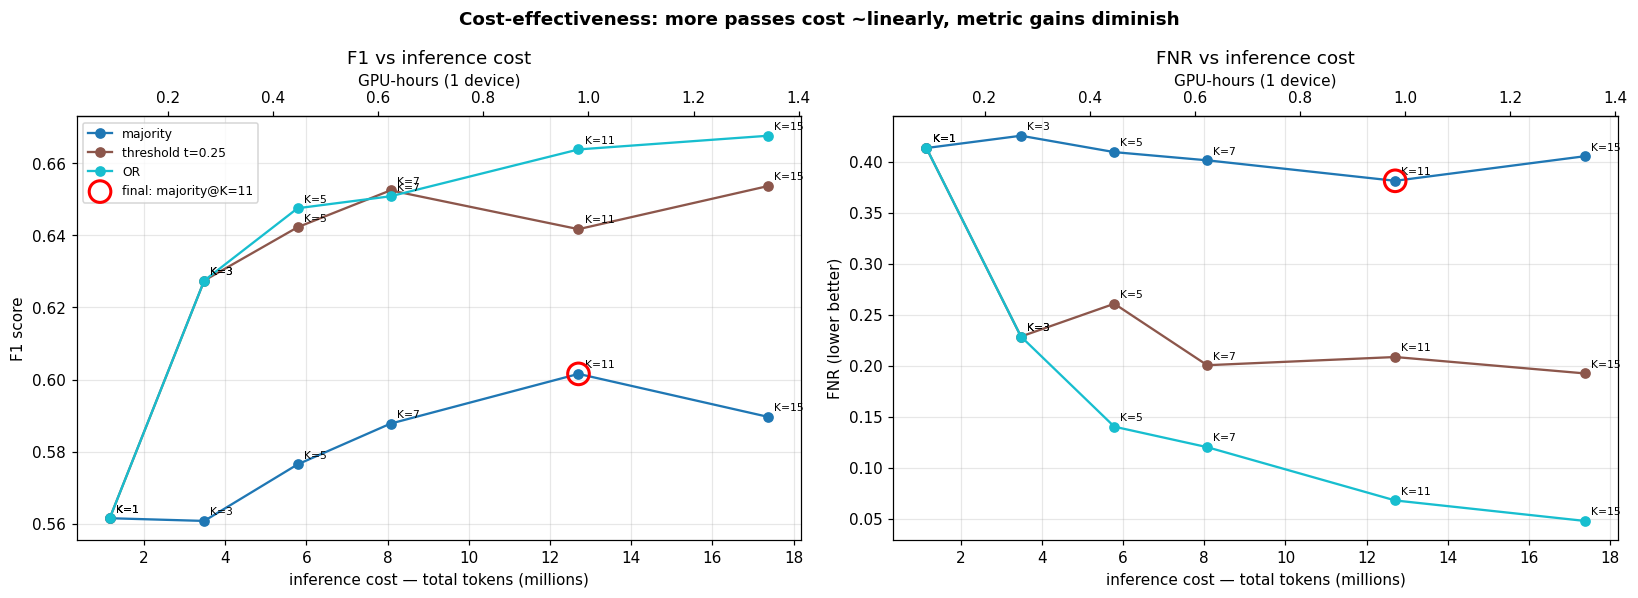

Final config (majority @ K=11): 12.70M tokens, 0.981 GPU-h (~11x the single-pass cost) -> FNR=0.382, F1=0.602, Acc=0.590


In [11]:
# ---- Cost-effectiveness plots: F1 vs cost and FNR vs cost ----
ce_rules = [("majority", "majority", 0.5),
            ("threshold t=0.25", "threshold", 0.25),
            ("OR", "or", 0.5)]
costM = {K: cost_at_K(K)[1].sum() / 1e6 for K in K_LIST}                    # total tokens (millions)
gpuh = {K: cost_at_K(K)[1].sum() / THROUGHPUT_TPS / 3600 * N_GPUS for K in K_LIST}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(ce_rules)))
for (lbl, rule, t), col in zip(ce_rules, colors):
    xs = [costM[K] for K in K_LIST]
    f1s = [metrics_at(K, rule, t)["f1"] for K in K_LIST]
    fnrs = [metrics_at(K, rule, t)["fnr"] for K in K_LIST]
    axL.plot(xs, f1s, "-o", color=col, label=lbl)
    axR.plot(xs, fnrs, "-o", color=col, label=lbl)
    for K, x, yf, yn in zip(K_LIST, xs, f1s, fnrs):
        axL.annotate(f"K={K}", (x, yf), fontsize=7, xytext=(4, 4), textcoords="offset points")
        axR.annotate(f"K={K}", (x, yn), fontsize=7, xytext=(4, 4), textcoords="offset points")

# highlight the final selected configuration
fx = costM[int(final.K)]
axL.scatter([fx], [final.f1], s=200, facecolors="none", edgecolors="red", linewidths=2,
            zorder=5, label=f"final: {final.label}@K={int(final.K)}")
axR.scatter([fx], [final.fnr], s=200, facecolors="none", edgecolors="red", linewidths=2, zorder=5)

k_gpu = 1e6 / THROUGHPUT_TPS / 3600 * N_GPUS   # total-tokens(M) -> GPU-hours
for ax, ylab, ttl in [(axL, "F1 score", "F1 vs inference cost"),
                      (axR, "FNR (lower better)", "FNR vs inference cost")]:
    ax.set_xlabel("inference cost — total tokens (millions)")
    ax.set_ylabel(ylab)
    ax.set_title(ttl)
    sec = ax.secondary_xaxis("top", functions=(lambda x: x * k_gpu, lambda g: g / k_gpu))
    sec.set_xlabel("GPU-hours (1 device)")
axL.legend(fontsize=8)
fig.suptitle("Cost-effectiveness: more passes cost ~linearly, metric gains diminish",
             fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Final config ({final.label} @ K={int(final.K)}): "
      f"{costM[int(final.K)]:.2f}M tokens, {gpuh[int(final.K)]:.3f} GPU-h "
      f"(~{costM[int(final.K)] / costM[1]:.0f}x the single-pass cost) "
      f"-> FNR={final.fnr:.3f}, F1={final.f1:.3f}, Acc={final.accuracy:.3f}")

## 9. Summary

A programmatic recap of the selected configuration and the headline numbers.

In [12]:
print("SELF-CONSISTENCY STUDY — SUMMARY")
print("=" * 60)
print(f"Dataset            : {PRIMARY_DATASET}  (n={N})")
print(f"Model              : {MODEL_DIR}  |  prompt: {PROMPT}")
print(f"Aggregation counts : {K_LIST}")
print(f"Rules studied      : majority, threshold {THRESHOLDS}, OR")
print("-" * 60)
print("Single-pass baseline (K=1):")
for m in METRICS:
    mu, sd = per_pass_stats[m]
    print(f"  {METRIC_LABEL[m]:22s}: {baseline_metrics[m]:.4f}  (per-pass mean {mu:.4f} ±{sd:.4f})")
print("-" * 60)
print(f"FINAL CONFIG       : {final.label} @ K={int(final.K)}")
for m in METRICS:
    d = final_metrics[m] - baseline_metrics[m]
    print(f"  {METRIC_LABEL[m]:22s}: {final_metrics[m]:.4f}   (Δ {d:+.4f} vs single-pass)")
_ft = cost_at_K(int(final.K))[1].sum()
print(f"  cost               : {_ft / 1e6:.2f}M tokens, "
      f"{_ft / THROUGHPUT_TPS / 3600 * N_GPUS:.3f} GPU-h "
      f"(~{_ft / cost_at_K(1)[1].sum():.0f}x single-pass)")
print(f"McNemar p (exact)  : {p_exact:.4f}  ->  {verdict} at α=0.05")
print("=" * 60)

SELF-CONSISTENCY STUDY — SUMMARY
Dataset            : context_assembler_compare_multiplicative_amplification  (n=498)
Model              : qwen3-8b-thinking-sc15  |  prompt: strict_exploitable_security
Aggregation counts : [1, 3, 5, 7, 11, 15]
Rules studied      : majority, threshold [0.25, 0.33, 0.5], OR
------------------------------------------------------------
Single-pass baseline (K=1):
  FNR (lower better)    : 0.4137  (per-pass mean 0.4035 ±0.0148)
  F1 score              : 0.5615  (per-pass mean 0.5792 ±0.0131)
  Accuracy              : 0.5422  (per-pass mean 0.5665 ±0.0160)
------------------------------------------------------------
FINAL CONFIG       : majority @ K=11
  FNR (lower better)    : 0.3815   (Δ -0.0321 vs single-pass)
  F1 score              : 0.6016   (Δ +0.0400 vs single-pass)
  Accuracy              : 0.5904   (Δ +0.0482 vs single-pass)
  cost               : 12.70M tokens, 0.981 GPU-h (~11x single-pass)
McNemar p (exact)  : 0.0127  ->  significant at α=0.05
